# Explorative Datenanalyse (EDA) - Stördaten
**Fokus:** Analyse des Datensatzes `uncleaned_aufschreibung_2024to2026.csv` zur Vorbereitung des ML/LSTM-Trainings.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pfad zur unbereinigten CSV-Datei
file_path = r'C:\Users\golde\PycharmProjects\pred_main_project_brueggen\data\lstm ready data\uncleaned_aufschreibung_2024to2026.csv'

print(f"Lese Rohdaten ein von: {file_path}")
# Wichtig: Trennzeichen ist Semikolon
df = pd.read_csv(file_path, sep=';', low_memory=False)
print(f"Datensatz erfolgreich geladen. Form: {df.shape[0]} Zeilen, {df.shape[1]} Spalten\n")

print("--- Die ersten 3 Zeilen des Datensatzes ---")
display(df.head(3))

Lese Rohdaten ein von: C:\Users\golde\PycharmProjects\pred_main_project_brueggen\data\lstm ready data\uncleaned_aufschreibung_2024to2026.csv
Datensatz erfolgreich geladen. Form: 33965 Zeilen, 36 Spalten

--- Die ersten 3 Zeilen des Datensatzes ---


,Datum,Wochentag,DatumNEU,KW,Std.,Log,Schicht,Zeit von,Zeit bis,Dauer Arbeits-zeit,...,Leistung Sollzeit zu Gesamtzeit,Anlagen-Laufzeit (- Org-Mangel),Takt Gesamt2,Leistung Anlage inkl. Anl. ausfall,Anlagen-Laufzeit (- Anlagen-ausfall),Takt Gesamt3,Leistung eff. Anlage ohne Anl.-Ausfall,Produktionszeit(min)/Std.,Takt Gesamt4,Leistung inkl. defizite
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-08,1,2024-01-08 00:00:00,2024/02,NaN,NaN,f,04:45:00,06:00:00,75.0,...,0.6799999999999999,75.0,12.5,0.6799999999999999,60.0,10.0,0.8499999999999999,60.0,10.0,0.8499999999999999
2,2024-01-08,1,2024-01-08 00:00:00,2024/02,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
print("--- Datentypen und Non-Null-Werteübersicht ---")
df.info()

--- Datentypen und Non-Null-Werteübersicht ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33965 entries, 0 to 33964
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Datum                                   23545 non-null  object 
 1   Wochentag                               10210 non-null  object 
 2   DatumNEU                                10210 non-null  object 
 3   KW                                      10217 non-null  object 
 4   Std.                                    6 non-null      object 
 5   Log                                     6 non-null      object 
 6   Schicht                                 7893 non-null   object 
 7   Zeit von                                7893 non-null   object 
 8   Zeit bis                                7893 non-null   object 
 9   Dauer Arbeits-zeit                      11318 non-null  float64
 10  Anzahl MA  

In [56]:
# 0. Bereinigung: Schmutzwerte in NaN umwandeln
messy_values = ['?', '-', 'NA', 'N/A', 'null', ' ', '', '#NV']
df.replace(messy_values, np.nan, inplace=True)

# 1. Freitext-Felder identifizieren und ausschließen
text_keywords = ['bemerkung', 'notiz', 'text', 'comment', 'beschreibung', 'info']
text_cols = [c for c in df.columns if any(kw in c.lower() for kw in text_keywords)]

# 2. Datums-/Zeit-Spalten identifizieren
time_keywords = ['datum', 'date', 'zeit', 'time', 'stempel', 'timestamp']
time_cols = [c for c in df.columns if any(kw in c.lower() for kw in time_keywords) and c not in text_cols]

# 3. DataFrame für die Analyse vorbereiten (Arbeitskopie)
df_analysis = df.drop(columns=text_cols, errors='ignore').copy()

# 4. Datentypen erzwingen
for tc in time_cols:
    df_analysis[tc] = pd.to_datetime(df_analysis[tc], errors='coerce')

for col in df_analysis.columns:
    if col not in time_cols:
        df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

num_features = df_analysis.select_dtypes(include=[np.number]).columns.tolist()
cat_features = df_analysis.select_dtypes(exclude=[np.number, 'datetime', 'datetimetz']).columns.tolist()

print(f"Analyse-Setup abgeschlossen.")
print(f"Features: {len(num_features)} numerisch, {len(cat_features)} kategorial.")

Analyse-Setup abgeschlossen.
Features: 25 numerisch, 0 kategorial.


In [52]:
# Numerische Statistik
num_stats = df_analysis[num_features].describe().T
num_stats['skewness'] = df_analysis[num_features].skew()
num_stats['kurtosis'] = df_analysis[num_stats.index].kurtosis() # Fehlerkorrektur bei Indizierung
display(num_stats.round(3))

# Warnhinweise für ML
highly_skewed = num_stats[abs(num_stats['skewness']) > 1.5].index.tolist()
if highly_skewed:
    print(f"🚨 Hinweis: Starke Schiefe in: {highly_skewed}. -> Log-Transformation in der Pipeline empfohlen.")

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Wochentag,10188.0,2.541000e+00,1.187000e+00,1.000,2.000,3.000,3.00,6.000000e+00,0.220,-0.987
KW,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Std.,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Log,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Schicht,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Anzahl MA,7733.0,4.263000e+00,8.660000e-01,1.000,4.000,4.000,5.00,9.000000e+00,0.161,0.400
Menge N.i. O.,34.0,1.176000e+00,3.870000e-01,1.000,1.000,1.000,1.00,2.000000e+00,1.777,1.225
Menge i. O. L4,1487.0,3.381000e+00,1.675000e+00,0.000,2.000,3.000,5.00,8.000000e+00,0.275,-0.789
Menge i. O. L5,6493.0,4.112000e+00,1.624000e+00,0.000,3.000,4.000,5.00,9.000000e+00,-0.178,-0.597
Menge Gesamt (Stück),7344.0,4.325000e+00,1.521000e+00,1.000,3.000,4.000,5.00,9.000000e+00,-0.118,-0.690


🚨 Hinweis: Starke Schiefe in: ['Menge   N.i. O.', 'Dauer Anlagen-Ausfall', 'Störung aufgrund Vormaterial', 'Dauer Anlagen-Ausfall intern', 'Dauer Logistik- Defizite', 'Leistung eff. Anlage ohne Anl.-Ausfall', 'Leistung  inkl. defizite']. -> Log-Transformation in der Pipeline empfohlen.


In [53]:
# --- Ergänzung: Statistische Übersicht kategorialer Features ---

print("\n--- 3. STATISTIKEN KATEGORIALER FEATURES ---")

# Freitextfelder identifizieren (um sie aus der kategorialen Analyse auszuschließen)
text_keywords = ['bemerkung', 'notiz', 'text', 'comment', 'beschreibung', 'info']
# Wir filtern die Spalten, die keine numerischen Daten sind und keine Freitext-Keywords enthalten
cat_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns 
            if not any(kw in c.lower() for kw in text_keywords)]

if len(cat_cols) > 0:
    # Berechnung der Kennzahlen
    cat_stats = pd.DataFrame(index=cat_cols)
    cat_stats['count'] = df[cat_cols].count()
    cat_stats['unique'] = df[cat_cols].nunique()
    cat_stats['top'] = df[cat_cols].mode().iloc[0]
    cat_stats['freq'] = [df[col].value_counts().iloc[0] if df[col].count() > 0 else 0 for col in cat_cols]
    cat_stats['missing_rate_%'] = (df[cat_cols].isnull().sum() / len(df) * 100).round(2)
    
    display(cat_stats)
    
    # ML-Warnungen für kategoriale Features
    high_cardinality = cat_stats[cat_stats['unique'] > 15].index.tolist()
    if high_cardinality:
        print(f"\n🚨 ML-Hinweis: Hohe Kardinalität in: {high_cardinality}")
        print("   -> Empfehlung: Kein One-Hot-Encoding. Nutze stattdessen Target Encoding oder Embeddings.")
    
    # Missing-Rate Hinweis
    high_missing = cat_stats[cat_stats['missing_rate_%'] > 20].index.tolist()
    if high_missing:
        print(f"\n⚠️ Hinweis: Hohe Missing-Rate (>20%) in: {high_missing}")
        print("   -> Empfehlung: Spalte prüfen, ob 'Imputation' oder 'Drop' sinnvoll ist.")
else:
    print("Keine relevanten kategorialen Features (außerhalb von Freitextfeldern) gefunden.")


--- 3. STATISTIKEN KATEGORIALER FEATURES ---


,count,unique,top,freq,missing_rate_%
Datum,23545,473,2025-11-10,108,30.68
Wochentag,10210,31,3,2620,69.94
DatumNEU,10210,212,2024-12-18 00:00:00,207,69.94
KW,10217,58,2024/51,321,69.92
Std.,6,6,2023-01-22,1,99.98
Log,6,6,2023-01-23,1,99.98
Schicht,7893,4,s,4004,76.76
Zeit von,7893,33,07:00:00,458,76.76
Zeit bis,7893,35,08:00:00,458,76.76
Menge i. O. L4,1488,18,2.0,208,95.62



🚨 ML-Hinweis: Hohe Kardinalität in: ['Datum', 'Wochentag', 'DatumNEU', 'KW', 'Zeit von', 'Zeit bis', 'Menge   i. O.       L4', 'Dauer  Org-Mangel', 'Dauer Anlagen-Ausfall', 'Störung aufgrund Vormaterial', 'Dauer Anlagen-Ausfall intern', 'Station/ OP', 'Leistung Sollzeit zu Gesamtzeit', 'Leistung Anlage inkl.  Anl. ausfall', 'Leistung eff. Anlage ohne Anl.-Ausfall', 'Leistung  inkl. defizite']
   -> Empfehlung: Kein One-Hot-Encoding. Nutze stattdessen Target Encoding oder Embeddings.

⚠️ Hinweis: Hohe Missing-Rate (>20%) in: ['Datum', 'Wochentag', 'DatumNEU', 'KW', 'Std.', 'Log', 'Schicht', 'Zeit von', 'Zeit bis', 'Menge   i. O.       L4', 'Dauer  Org-Mangel', 'Dauer Anlagen-Ausfall', 'Störung aufgrund Vormaterial', 'Dauer Anlagen-Ausfall intern', 'Station/ OP', 'Anzahl/Std.', 'Fehlercode', 'Leistung Sollzeit zu Gesamtzeit', 'Leistung Anlage inkl.  Anl. ausfall', 'Leistung eff. Anlage ohne Anl.-Ausfall', 'Leistung  inkl. defizite']
   -> Empfehlung: Spalte prüfen, ob 'Imputation' oder 

In [51]:
# Suche nach typischen Target-Namen
target_candidates = ['störfall', 'target', 'label', 'class', 'status', 'Station/ OP']
TARGET_COL = next((c for c in df_analysis.columns if any(t in c.lower() for t in target_candidates)), None)

if TARGET_COL:
    print(f"Target identifiziert: {TARGET_COL}")
    unique_vals = df_analysis[TARGET_COL].nunique()
    ml_task = "Regression" if unique_vals > 20 else "Klassifikation"
    print(f"Erkannte Aufgabe: {ml_task}")
    
    # Visualisierung
    if ml_task == "Klassifikation":
        sns.countplot(x=df_analysis[TARGET_COL].dropna())
    else:
        sns.histplot(df_analysis[TARGET_COL].dropna(), kde=True)
    plt.show()

In [50]:
print("--- Analyse von Fehlwerten (Missing Values) ---")
missing_values = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Fehlwerte Anz.', '% von Gesamt'])
missing_table = missing_table[missing_table['Fehlwerte Anz.'] > 0].sort_values('% von Gesamt', ascending=False)

if len(missing_table) > 0:
    display(missing_table)
else:
    print("Keine Fehlwerte im Datensatz vorhanden.")

--- Analyse von Fehlwerten (Missing Values) ---


,Fehlwerte Anz.,% von Gesamt
Fehlercode,33964,99.997056
Std.,33959,99.982335
Log,33959,99.982335
Menge N.i. O.,33931,99.899897
Dauer Org-Mangel,33918,99.861622
Dauer Logistik- Defizite,33850,99.661416
Störung aufgrund Vormaterial,33636,99.031356
Anzahl/Std.,33620,98.984248
Menge i. O. L4,32477,95.619020
Dauer Anlagen-Ausfall,32167,94.706315


## 1. Statistische Übersicht der aggregierten Features
Um die Verteilung unserer Prädiktoren im Detail zu verstehen, betrachten wir verschiedene statistische Maßzahlen:
* **Lageparameter:** Mean (Mittelwert) vs. Median (50%-Quantil).
* **Streuung:** Standardabweichung (std) und Interquartilsabstand (IQR).
* **Form der Verteilung:** Schiefe (Skewness) & Wölbung (Kurtosis).
* **Kategorial:** Kardinalität (Anzahl einzigartiger Werte) und Modus.

In [26]:
print("--- 1. STATISTIKEN NUMERISCHER FEATURES ---")
if len(num_features) > 0:
    num_stats = df_analysis[num_features].describe().T
    num_stats['skewness'] = df_analysis[num_features].skew()   
    num_stats['kurtosis'] = df_analysis[num_features].kurtosis() 
    
    if '75%' in num_stats.columns and '25%' in num_stats.columns:
        num_stats['IQR'] = num_stats['75%'] - num_stats['25%'] 
        num_stats = num_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'IQR', 'skewness', 'kurtosis']]
    else:
        num_stats = num_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'skewness', 'kurtosis']]
        
    num_stats = num_stats.rename(columns={'50%': 'median'})
    display(num_stats.round(3))
    
    highly_skewed = num_stats[abs(num_stats['skewness']) > 1.5].index.tolist()
    if highly_skewed:
        print(f"\n🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):")
        print(f"   {highly_skewed}")
        print("   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!")
else:
    print("Keine numerischen Features vorhanden.")


print("\n--- 2. STATISTIKEN KATEGORIALER FEATURES ---")
if len(cat_features) > 0:
    cat_stats = df_analysis[cat_features].astype(object).describe().T
    cat_stats['missing_%'] = (df_analysis[cat_features].isnull().sum() / len(df_analysis) * 100).values
    
    display(cat_stats.round(2))
    
    high_cardinality = cat_stats[cat_stats['unique'] > 15].index.tolist()
    if high_cardinality:
        print(f"\n🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):")
        print(f"   {high_cardinality}")
        print("   -> Empfehlung: Hier kein One-Hot-Encoding verwenden. Besser: Target Encoding, Frequency-Encoding oder Embeddings.")
else:
    print("Keine kategorialen Features vorhanden.")

--- 1. STATISTIKEN NUMERISCHER FEATURES ---


,count,mean,median,std,min,max,IQR,skewness,kurtosis
Anzahl MA,996.0,5.053,5.000,2.608,1.000,9.000,4.000,-0.020,-1.238
Temperatur,1050.0,19.871,19.737,5.005,3.803,38.289,6.745,-0.002,0.041



--- 2. STATISTIKEN KATEGORIALER FEATURES ---


,count,unique,top,freq,missing_%
Station,826,4,B,242,21.33
Störfall,1002,2,N,898,4.57


In [20]:
print("--- Analyse von Duplikaten und zeitlichen Überlappungen ---")
dups_exact = df.duplicated().sum()
print(f"Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): {dups_exact} ({dups_exact/len(df)*100:.2f}%)")

# Diese Spalten sind kritisch für deine LSTM-Zeitreihen
time_key_cols = ['DatumNEU', 'Zeit von', 'Zeit bis']
if all(col in df.columns for col in time_key_cols):
    dups_time = df.duplicated(subset=time_key_cols).sum()
    print(f"Anzahl Zeilen mit identischem Zeitfenster ({', '.join(time_key_cols)}): {dups_time} ({dups_time/len(df)*100:.2f}%)")
    if dups_time > 0:
        print(f"\n⚠️ ML-Hinweis: {dups_time} Zeilen weisen zeitliche Überlappungen auf.")
        print("   Diese müssen vor einem LSTM-Modelltraining aggregiert werden, um die Zeitreihe nicht zu verfälschen!")
else:
    print("Hinweis: Zeit-Schlüsselspalten für den Überlappungs-Check wurden nicht vollständig gefunden.")

--- Analyse von Duplikaten und zeitlichen Überlappungen ---
Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): 22740 (66.95%)
Anzahl Zeilen mit identischem Zeitfenster (DatumNEU, Zeit von, Zeit bis): 30762 (90.57%)

⚠️ ML-Hinweis: 30762 Zeilen weisen zeitliche Überlappungen auf.
   Diese müssen vor einem LSTM-Modelltraining aggregiert werden, um die Zeitreihe nicht zu verfälschen!


In [22]:
# --- VORBEREITUNG: 'Datum' sowie Freitexte ('Bemerkung', 'Bemerkung_norm') ausschließen ---
cols_to_exclude = ['Datum', 'Bemerkung', 'Bemerkung_norm']
df_stats = df.drop(columns=cols_to_exclude, errors='ignore')

# SICHERHEITSNETZ 1: Falls der Code NACH der Aggregation läuft, 
# rekonstruieren wir 'DatumNEU' blitzschnell aus dem Zeitstempel
if 'DatumNEU' not in df_stats.columns:
    if 'Timestamp_Start' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_Start']).dt.strftime('%Y-%m-%d')
    elif 'Timestamp_End' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_End']).dt.strftime('%Y-%m-%d')

# Listen bereinigen (nur Spalten behalten, die existieren und nicht ausgeschlossen wurden)
num_features = [c for c in num_features if c in df_stats.columns and c not in cols_to_exclude]
cat_features = [c for c in cat_features if c in df_stats.columns and c not in cols_to_exclude]

# Sicherstellen, dass DatumNEU definitiv in den kategorialen Features landet
if 'DatumNEU' in df_stats.columns and 'DatumNEU' not in cat_features:
    cat_features.append('DatumNEU')


print("--- 1. STATISTIKEN NUMERISCHER FEATURES ---")
if len(num_features) > 0:
    num_stats = df_stats[num_features].describe().T
    num_stats['skewness'] = df_stats[num_features].skew()   
    num_stats['kurtosis'] = df_stats[num_features].kurtosis() 
    num_stats['IQR'] = num_stats['75%'] - num_stats['25%'] 
    
    num_stats = num_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'IQR', 'skewness', 'kurtosis']]
    num_stats = num_stats.rename(columns={'50%': 'median'})
    display(num_stats.round(3))
    
    highly_skewed = num_stats[abs(num_stats['skewness']) > 1.5].index.tolist()
    if highly_skewed:
        print(f"\n🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):")
        print(f"   {highly_skewed}")
        print("   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!")
else:
    print("Keine numerischen Features vorhanden.")


print("\n--- 2. STATISTIKEN KATEGORIALER FEATURES ---")
if len(cat_features) > 0:
    # .astype(object) zwingt Pandas dazu, auch Datetime-Spalten 
    # wie 'DatumNEU' sauber mit 'count', 'unique' und 'top' in der Tabelle zu beschreiben!
    cat_stats = df_stats[cat_features].astype(object).describe().T
    
    # Fehlende Werte in Prozent ergänzen
    cat_stats['missing_%'] = (df_stats[cat_features].isnull().sum() / len(df_stats) * 100).values
    
    display(cat_stats.round(2))
    
    # Warnsystem für hohe Kardinalität
    # 'DatumNEU' wird hier ignoriert, da ein Datum logischerweise viele einzigartige Werte besitzt
    high_cardinality = cat_stats[(cat_stats['unique'] > 15) & (cat_stats.index != 'DatumNEU')].index.tolist()
    if high_cardinality:
        print(f"\n🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):")
        print(f"   {high_cardinality}")
        print("   -> Empfehlung: Hier kein One-Hot-Encoding verwenden (bläht die Feature-Matrix extrem auf).")
        print("      Besser: Target Encoding, Frequenz-Encoding oder eine Embedding-Layer vorschalten.")
else:
    print("Keine kategorialen Features vorhanden.")

NameError: name 'num_features' is not defined

## 3. Datenqualität
Gute Modelle erfordern saubere Daten. Wir analysieren Missing Values & Duplikate.

Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):


,Missing_Count,Percent
Fehlercode,4956,99.979827
Std.,4955,99.959653
Log,4955,99.959653
Station/ OP_2,4929,99.435142
Dauer Org-Mangel,4910,99.051846
Dauer Logistik- Defizite,4843,97.700222
Störung aufgrund Vormaterial,4632,93.443615
Anzahl/ Std.,4619,93.181360
Leistung inkl. defizite,3863,77.930200
Leistung eff. Anlage ohne Anl.-Ausfall,3857,77.809159


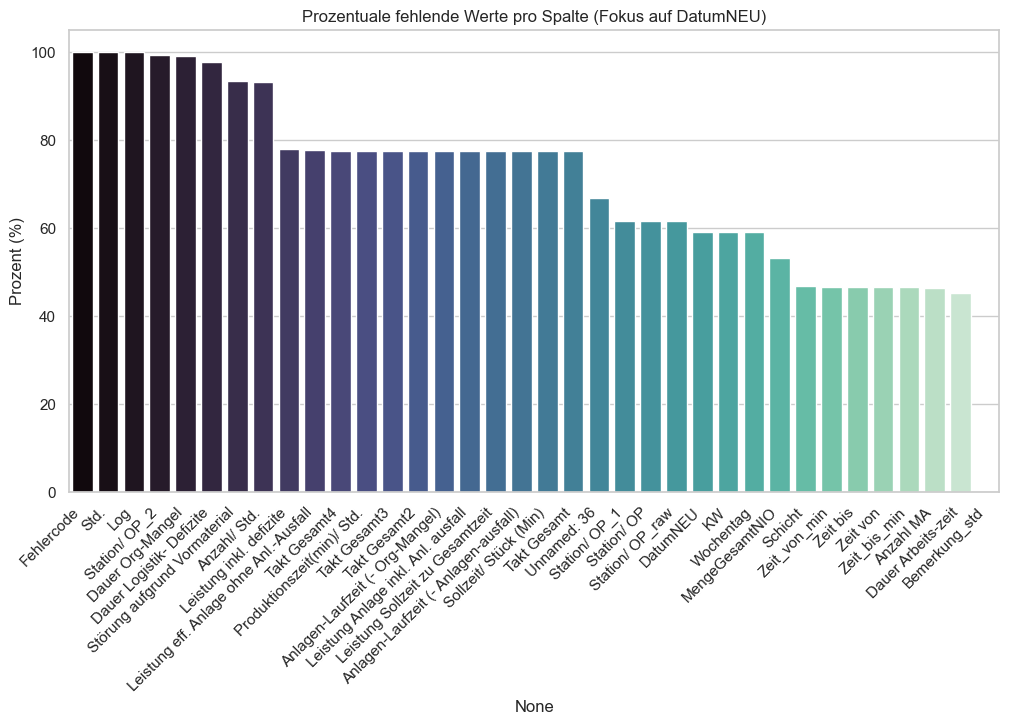

Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): 183 (3.69%)
Anzahl Zeilen mit identischem Zeitfenster (DatumNEU, Zeit von, Zeit bis): 3631 (73.25%)
⚠️ ML-Hinweis: 3631 Zeilen sind zeitliche Überlappungen (z.B. mehrere Aufträge pro Schicht).
   Diese MÜSSEN vor dem LSTM-Training aggregiert werden, um die Zeitreihe nicht zu verfälschen!


In [13]:
# --- 1. MISSING VALUES (Fokus auf DatumNEU) ---
# Wir ignorieren die alte 'Datum'-Spalte vollständig, damit nur 'DatumNEU' analysiert wird
df_quality = df.drop(columns=['Datum','Bemerkung','Bemerkung_norm'], errors='ignore')

missing_stats = df_quality.isnull().sum()
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)
missing_percent = (missing_stats / len(df_quality)) * 100

missing_df = pd.DataFrame({'Missing_Count': missing_stats, 'Percent': missing_percent})

if not missing_df.empty:
    print("Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):")
    display(missing_df)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percent'], palette='mako')
    plt.xticks(rotation=45, ha='right')
    plt.title("Prozentuale fehlende Werte pro Spalte (Fokus auf DatumNEU)")
    plt.ylabel("Prozent (%)")
    plt.show()
else:
    print("Keine fehlenden Werte in den relevanten Spalten (inkl. DatumNEU) gefunden.")


# --- 2. DUPLIKATE (Kontext-Erweiterung) ---
# A) Exakte Duplikate über alle Spalten hinweg
dups_exact = df.duplicated().sum()
print(f"Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): {dups_exact} ({dups_exact/len(df)*100:.2f}%)")

# B) Zeitfenster-Duplikate (Mehrere Zeilen/Aufträge zum selben Zeitpunkt)
time_key_cols = ['DatumNEU', 'Zeit von', 'Zeit bis']
if all(col in df.columns for col in time_key_cols):
    dups_time = df.duplicated(subset=time_key_cols).sum()
    print(f"Anzahl Zeilen mit identischem Zeitfenster ({', '.join(time_key_cols)}): {dups_time} ({dups_time/len(df)*100:.2f}%)")
    if dups_time > 0:
        print(f"⚠️ ML-Hinweis: {dups_time} Zeilen sind zeitliche Überlappungen (z.B. mehrere Aufträge pro Schicht).")
        print("   Diese MÜSSEN vor dem LSTM-Training aggregiert werden, um die Zeitreihe nicht zu verfälschen!")

## 3. Datenqualität
Gute Modelle erfordern saubere Daten. Wir analysieren:
* **Missing Values:** Wichtig für die Imputationsstrategie.
* **Duplikate:** Können zu Überanpassung (Overfitting) führen, wenn sie in Train/Test landen.

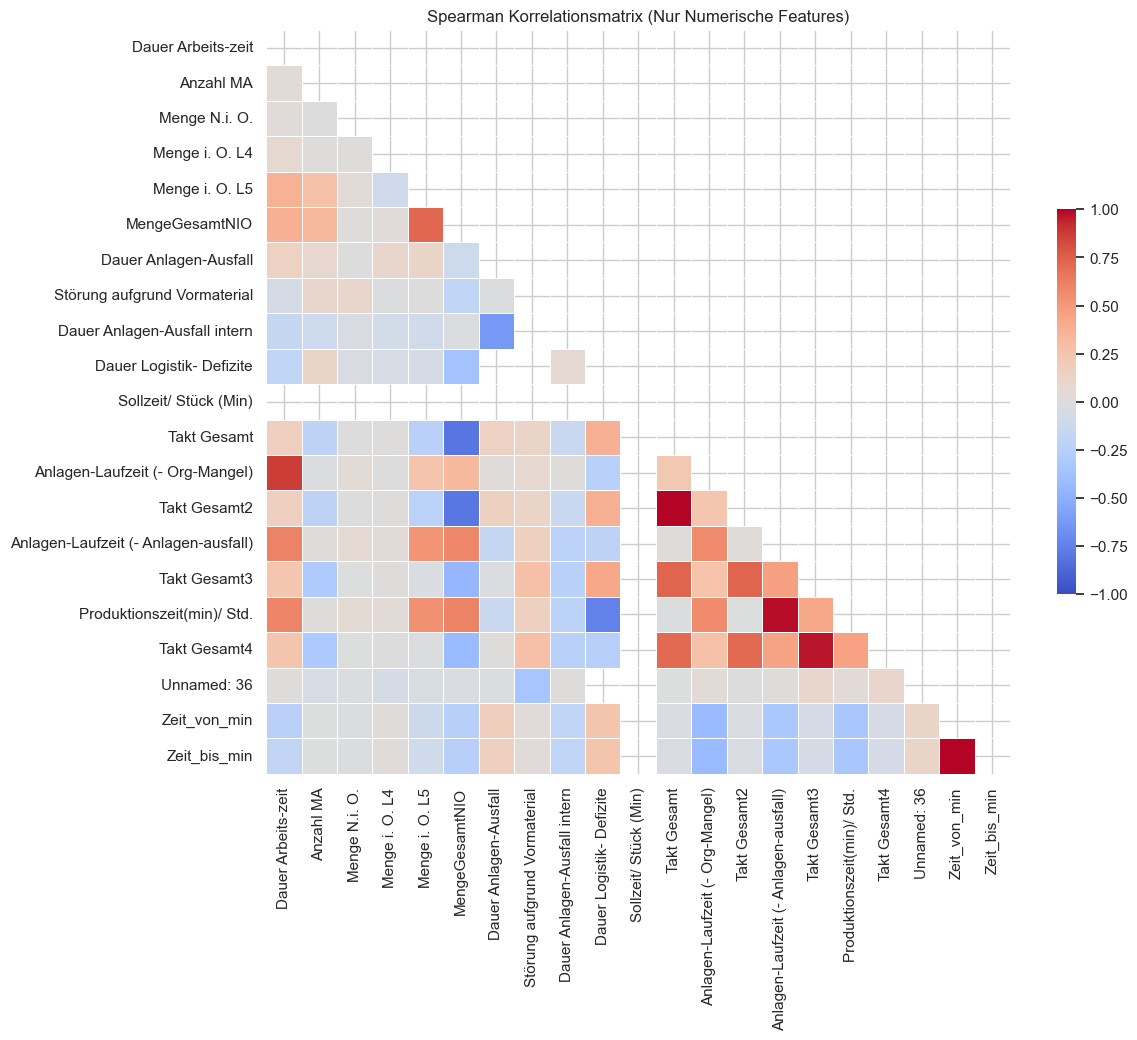

🚨 Warnung: Folgende Feature-Paare sind stark korreliert (>0.85). Eines davon sollte ggf. entfernt werden:
- Dauer Arbeits-zeit und Anlagen-Laufzeit (- Org-Mangel) (r = 0.87)
- Takt Gesamt und Takt Gesamt2 (r = 0.99)
- Anlagen-Laufzeit (- Anlagen-ausfall) und Produktionszeit(min)/ Std. (r = 0.98)
- Takt Gesamt3 und Takt Gesamt4 (r = 0.97)
- Zeit_von_min und Zeit_bis_min (r = 0.99)


In [14]:
if len(num_features) > 1:
    corr_matrix = df[num_features].corr(method='spearman') # Spearman ist robuster gegen Ausreißer
    
    # Maske für das obere Dreieck
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Spearman Korrelationsmatrix (Nur Numerische Features)")
    plt.show()
    
    # Redundante Features markieren (Korrelation > 0.85)
    high_corr_var = np.where(np.abs(corr_matrix) > 0.85)
    high_corr_pairs = [(corr_matrix.columns[x], corr_matrix.columns[y]) 
                       for x, y in zip(*high_corr_var) if x != y and x < y]
    if high_corr_pairs:
        print("🚨 Warnung: Folgende Feature-Paare sind stark korreliert (>0.85). Eines davon sollte ggf. entfernt werden:")
        for pair in high_corr_pairs:
            print(f"- {pair[0]} und {pair[1]} (r = {corr_matrix.loc[pair[0], pair[1]]:.2f})")
    else:
        print("Keine stark korrelierten Feature-Paare gefunden.")

In [16]:
# Dateipfad an neue Processdata-Datei angepasst
FILE_PATH = r"C:\Users\golde\PycharmProjects\pred_main_project_brueggen\data\lstm ready data\M200310_processdata_2024_2026.csv"
DELIMITER = ";"
# Target auf None gesetzt, damit deine Logik aus dem Original-Skript ('status') automatisch greift
TARGET_COL = None 

print(f"Lese Rohdaten ein von: {FILE_PATH}")
df_raw = pd.read_csv(FILE_PATH, sep=DELIMITER, low_memory=False)

# DataFrame für die nachfolgende Original-Logik initialisieren
df = df_raw.copy()
num_features = df.select_dtypes(include=np.number).columns.tolist()
cat_features = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns.tolist()

Lese Rohdaten ein von: C:\Users\golde\PycharmProjects\pred_main_project_brueggen\data\lstm ready data\M200310_processdata_2024_2026.csv


In [19]:
# --- VORBEREITUNG: 'Datum' sowie Freitexte ('Bemerkung', 'Bemerkung_norm') ausschließen ---
cols_to_exclude = ['Datum', 'Bemerkung', 'Bemerkung_norm']
df_stats = df.drop(columns=cols_to_exclude, errors='ignore')

# SICHERHEITSNETZ 1: Falls der Code NACH der Aggregation läuft, 
if 'DatumNEU' not in df_stats.columns:
    if 'Timestamp_Start' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_Start']).dt.strftime('%Y-%m-%d')
    elif 'Timestamp_End' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_End']).dt.strftime('%Y-%m-%d')

# Listen bereinigen
num_features = [c for c in num_features if c in df_stats.columns and c not in cols_to_exclude]
cat_features = [c for c in cat_features if c in df_stats.columns and c not in cols_to_exclude]

if 'DatumNEU' in df_stats.columns and 'DatumNEU' not in cat_features:
    cat_features.append('DatumNEU')

print("--- 1. STATISTIKEN NUMERISCHER FEATURES ---")
if len(num_features) > 0:
    num_stats = df_stats[num_features].describe().T
    num_stats['skewness'] = df_stats[num_features].skew()   
    num_stats['kurtosis'] = df_stats[num_features].kurtosis() 
    num_stats['IQR'] = num_stats['75%'] - num_stats['25%'] 
    
    num_stats = num_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'IQR', 'skewness', 'kurtosis']]
    num_stats = num_stats.rename(columns={'50%': 'median'})
    display(num_stats.round(3))
    
    highly_skewed = num_stats[abs(num_stats['skewness']) > 1.5].index.tolist()
    if highly_skewed:
        print(f"\n🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):")
        print(f"   {highly_skewed}")
        print("   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!")
else:
    print("Keine numerischen Features vorhanden.")

print("\n--- 2. STATISTIKEN KATEGORIALER FEATURES ---")
if len(cat_features) > 0:
    cat_stats = df_stats[cat_features].astype(object).describe().T
    cat_stats['missing_%'] = (df_stats[cat_features].isnull().sum() / len(df_stats) * 100).values
    display(cat_stats.round(2))
    
    high_cardinality = cat_stats[(cat_stats['unique'] > 15) & (cat_stats.index != 'DatumNEU')].index.tolist()
    if high_cardinality:
        print(f"\n🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):")
        print(f"   {high_cardinality}")
        print("   -> Empfehlung: Hier kein One-Hot-Encoding verwenden (bläht die Feature-Matrix extrem auf).")
        print("      Besser: Target Encoding, Frequenz-Encoding oder eine Embedding-Layer vorschalten.")
else:
    print("Keine kategorialen Features vorhanden.")

--- 1. STATISTIKEN NUMERISCHER FEATURES ---


,count,mean,median,std,min,max,IQR,skewness,kurtosis
Kundenauftragsnummer,31556.0,3.033246e+07,30332241.0,12966.804,30250504.0,30353111.0,22086.0,-0.543,1.777
Kundenauftragspos.,31556.0,3.419320e+02,330.0,202.628,10.0,850.0,340.0,0.147,-1.031
Auftrag,31556.0,5.050492e+08,505029398.0,318339.452,504503239.0,505603444.0,570536.0,0.030,-1.240
Materialnummer,31556.0,5.151151e+08,515102192.0,22693.904,515102020.0,515200656.0,21257.0,1.914,2.737
Vorgang,31529.0,1.000000e+01,10.0,0.000,10.0,10.0,0.0,0.000,0.000
Vorgangsmenge (MEINH),31557.0,1.186000e+00,1.0,32.959,1.0,5856.0,0.0,177.643,31557.000
Rückgem. Gutmenge (GMEIN),25701.0,2.000000e+00,1.0,160.278,0.0,25696.0,0.0,160.315,25701.000
Rückgem. Gutmenge (MEINH),5856.0,1.000000e+00,1.0,0.000,1.0,1.0,0.0,0.000,0.000



🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):
   ['Materialnummer', 'Vorgangsmenge (MEINH)', 'Rückgem. Gutmenge (GMEIN)']
   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!

--- 2. STATISTIKEN KATEGORIALER FEATURES ---


,count,unique,top,freq,missing_%
Serialnummer,31556,31550,TEST BESCHICHTUNG,2,0.01
Material-Text,31556,31,MV STW ROH,24721,0.01
Arbeitsplatz,31529,1,M200310,31529,0.09
Kurztext Vorgang,31529,1,MH_STW_komplettieren,31529,0.09
Basismengeneinheit (=GMEIN),25701,1,ST,25701,18.56
Ende Durchf.(Dat.),25700,398,2024-06-12,97,18.56
Ende Durchf.(Zeit),25700,20207,11:45:07,7,18.56
Steuerschlüssel,5856,1,ZMEW,5856,81.44
Mengeneinheit Vrg. (=MEINH),5857,1,ST,5857,81.44
Ist-Ende Vorg.,5856,81,2026-01-20,106,81.44



🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):
   ['Serialnummer', 'Material-Text', 'Ende Durchf.(Dat.)', 'Ende Durchf.(Zeit)', 'Ist-Ende Vorg.', 'Istendzt.Durchf.']
   -> Empfehlung: Hier kein One-Hot-Encoding verwenden (bläht die Feature-Matrix extrem auf).
      Besser: Target Encoding, Frequenz-Encoding oder eine Embedding-Layer vorschalten.


Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):


,Missing_Count,Percent
Rückgem. Gutmenge (MEINH),25702,81.443691
Systemstatus,25702,81.443691
Userfeld 1 (10),25702,81.443691
Istendzt.Durchf.,25702,81.443691
Ist-Ende Vorg.,25702,81.443691
Steuerschlüssel,25702,81.443691
Mengeneinheit Vrg. (=MEINH),25701,81.440522
Ende Durchf.(Zeit),5858,18.562647
Ende Durchf.(Dat.),5858,18.562647
Basismengeneinheit (=GMEIN),5857,18.559478


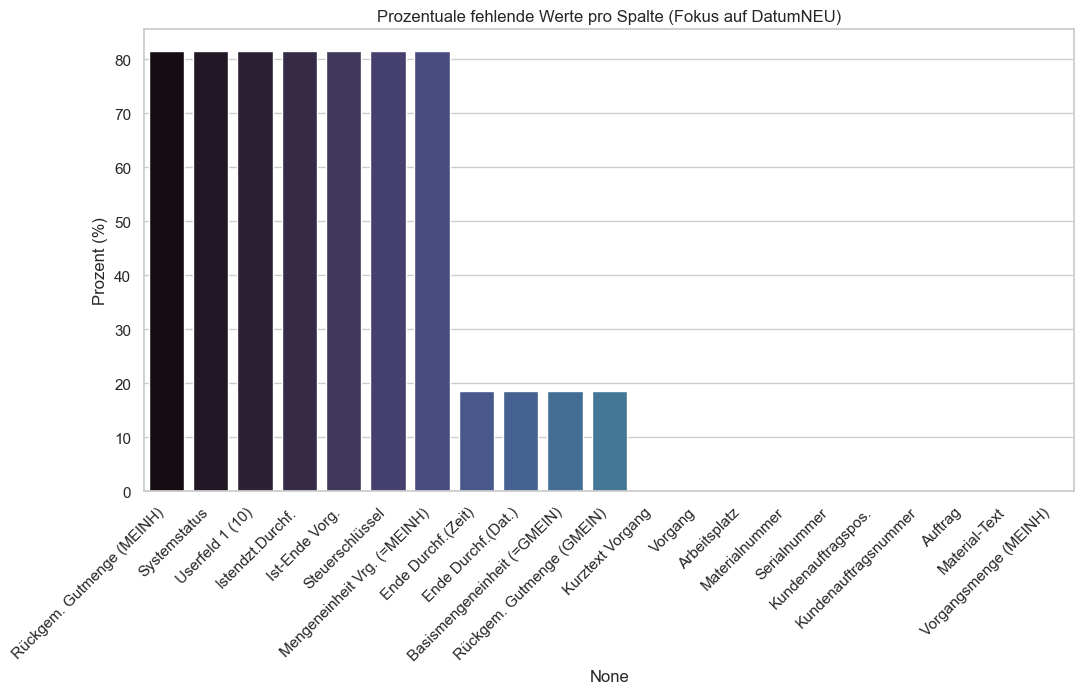

Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): 0 (0.00%)


In [18]:
# --- 1. MISSING VALUES (Fokus auf DatumNEU) ---
df_quality = df.drop(columns=['Datum','Bemerkung','Bemerkung_norm'], errors='ignore')

missing_stats = df_quality.isnull().sum()
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)
missing_percent = (missing_stats / len(df_quality)) * 100

missing_df = pd.DataFrame({'Missing_Count': missing_stats, 'Percent': missing_percent})

if not missing_df.empty:
    print("Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):")
    display(missing_df)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percent'], palette='mako')
    plt.xticks(rotation=45, ha='right')
    plt.title("Prozentuale fehlende Werte pro Spalte (Fokus auf DatumNEU)")
    plt.ylabel("Prozent (%)")
    plt.show()
else:
    print("Keine fehlenden Werte in den relevanten Spalten (inkl. DatumNEU) gefunden.")

# --- 2. DUPLIKATE (Kontext-Erweiterung) ---
dups_exact = df.duplicated().sum()
print(f"Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): {dups_exact} ({dups_exact/len(df)*100:.2f}%)")

time_key_cols = ['DatumNEU', 'Zeit von', 'Zeit bis']
if all(col in df.columns for col in time_key_cols):
    dups_time = df.duplicated(subset=time_key_cols).sum()
    print(f"Anzahl Zeilen mit identischem Zeitfenster ({', '.join(time_key_cols)}): {dups_time} ({dups_time/len(df)*100:.2f}%)")
    if dups_time > 0:
        print(f"⚠️ ML-Hinweis: {dups_time} Zeilen sind zeitliche Überlappungen (z.B. mehrere Aufträge pro Schicht).")
        print("   Diese MÜSSEN vor dem LSTM-Training aggregiert werden, um die Zeitreihe nicht zu verfälschen!")